In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import PolynomialFeatures

[27.35195229]
-2.1872433917295835


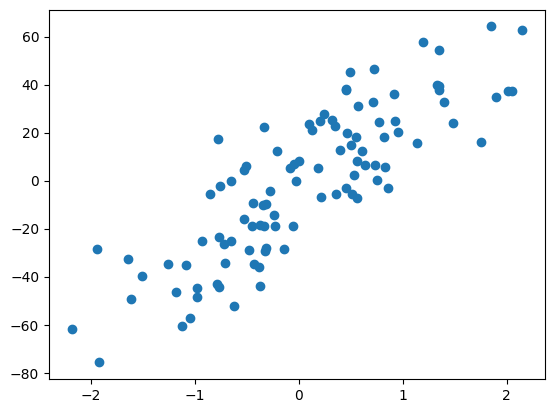

In [20]:
x,y = make_regression(n_samples = 100, n_features = 1, n_informative = 1, n_targets = 1, noise = 20, random_state = 13)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)
plt.scatter(x, y)
lr = LinearRegression()
lr.fit(x_train, y_train)
print(lr.coef_)
print(lr.intercept_)

C:\Users\bhard\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\bhard\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\bhard\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.151e+04, tolerance: 7.106e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented 

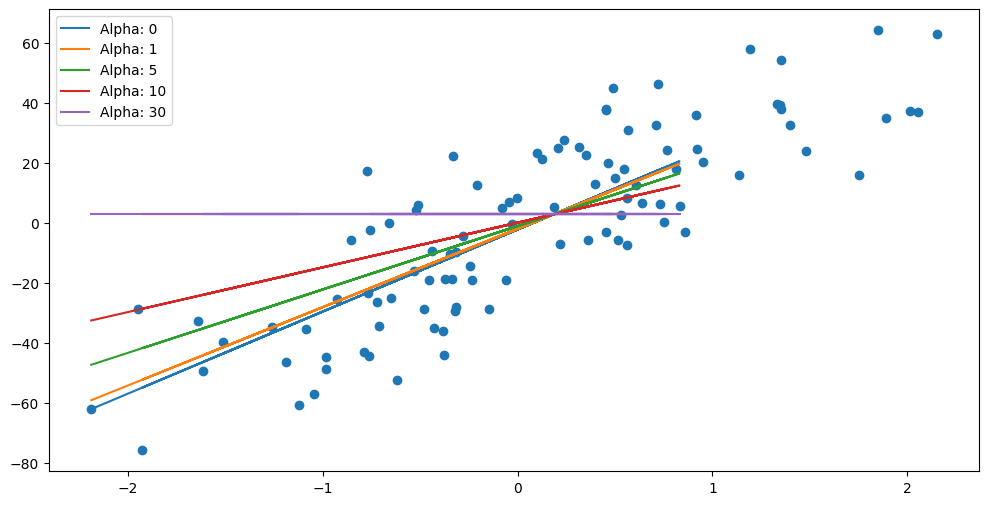

In [21]:
alphas = [0, 1, 5, 10, 30]
plt.figure(figsize = (12, 6))
plt.scatter(x, y)
for i in alphas:
    L = Lasso(alpha = i)
    L.fit(x_train, y_train)
    plt.plot(x_test, L.predict(x_test), label = 'Alpha: {}'.format(i))
plt.legend()
plt.show()

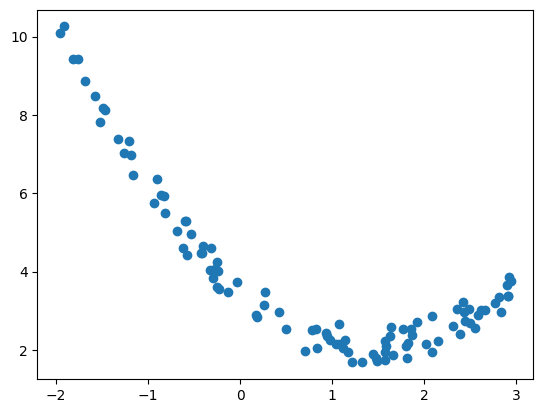

In [22]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1**2 - 2 * x1 + 3 + np.random.rand(m, 1)

plt.scatter(x1, x2)
plt.show()

C:\Users\bhard\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\bhard\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\bhard\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.502e+00, tolerance: 4.485e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented 

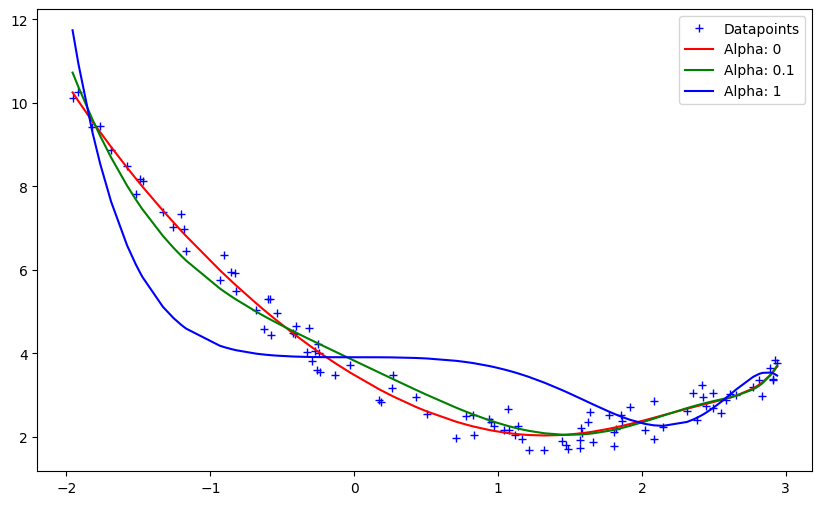

In [24]:
def get_preds_lasso(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree = 16)),
        ('lasso', Lasso(alpha = alpha))
    ]) 
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 0.1, 1]
cs = ['r', 'g', 'b']

plt.figure(figsize = (10, 6))
plt.plot(x1, x2, 'b+', label = 'Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_lasso(x1, x2, alpha)
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label = 'Alpha: {}'.format(alpha))

plt.legend()
plt.show()